In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import PercentFormatter
import math

In [12]:
# Processed data
repo_path = os.getcwd()
data_path = os.path.join(repo_path, 'Final_Processed_Datasets')
file_name = 'train_processed.csv'
save_path = os.path.join(data_path, file_name)
df = pd.read_csv(save_path, sep=';')

# Compare with the raw data
test_path = (os.path.join(repo_path, 'ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data'))
raw_data_name = 'train.csv'
test_save_path = os.path.join(test_path, raw_data_name)
raw_df = pd.read_csv(test_save_path, sep=';')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105643 entries, 0 to 105642
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   interest_expense             105643 non-null  float64
 1   payables_curr                105643 non-null  float64
 2   receivables_curr             105643 non-null  float64
 3   assets_curr_total            105643 non-null  float64
 4   assets_total                 105643 non-null  float64
 5   cash_equiv                   105643 non-null  float64
 6   curr_ratio                   105643 non-null  float64
 7   debt_nw_ratio                105643 non-null  float64
 8   depreciation                 105643 non-null  float64
 9   ebitda_margin                105643 non-null  float64
 10  ebit                         105643 non-null  float64
 11  ebitda                       105643 non-null  float64
 12  eff_tang_nw_actual           105643 non-null  float64
 13 

In [14]:
pd.options.display.float_format = '{:20.2f}'.format
df.head(n=5)

,interest_expense,payables_curr,receivables_curr,assets_curr_total,assets_total,cash_equiv,curr_ratio,debt_nw_ratio,depreciation,ebitda_margin,...,working_cap,interest_expense_is_missing,payables_curr_is_missing,receivables_curr_is_missing,depreciation_is_missing,cash_equiv_is_missing,roe_is_missing,id,obs_date,default
0,10013130.50,46484313.84,104004997.78,157725077.45,745137703.72,25434813.23,0.77,0.85,54231699.48,0.14,...,-48165350.34,0,0,0,0,0,0,41424861,2019-12-31,0
1,0.00,17976.06,24207.01,27083.43,1159840.00,412.03,0.09,-5.95,39704.47,0.32,...,-288514.86,1,0,0,0,0,1,6082057,2015-12-31,0
2,4780.55,16323.56,37279.02,139073.08,304599.81,99836.93,2.68,-0.12,20875.55,0.16,...,87163.12,0,0,0,0,0,0,90950563,2017-12-31,0
3,16376.49,225365.62,148705.48,753385.09,1601834.31,250137.79,2.99,0.01,77470.98,0.13,...,501254.36,0,0,0,0,0,0,55981025,2020-12-31,0
4,2289.18,17148.01,3361.21,53589.10,184162.72,47591.74,2.05,-14.19,7369.66,0.07,...,27434.00,0,0,0,0,0,1,13559301,2017-12-31,0


## Checking imbalance

--- Target Variable (Default) Distribution ---
Non-Defaults (0): 99,429 (94.12%)
Defaults (1):     6,214 (5.88%)



C:\Users\ydmar\AppData\Local\Temp\ipykernel_26820\3673891208.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='default', palette=['#2ecc71', '#e74c3c'])


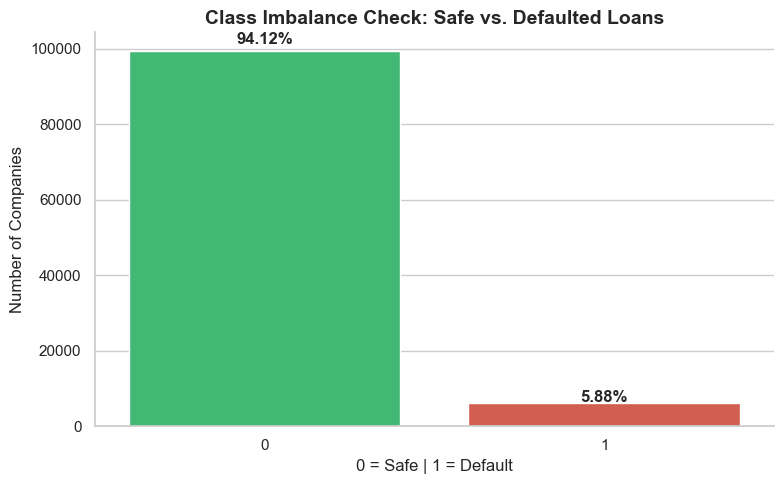

In [15]:
default_counts = df['default'].value_counts()
default_percentages = df['default'].value_counts(normalize=True) * 100

print("--- Target Variable (Default) Distribution ---")
print(f"Non-Defaults (0): {default_counts.get(0, 0):,} ({default_percentages.get(0, 0):.2f}%)")
print(f"Defaults (1):     {default_counts.get(1, 0):,} ({default_percentages.get(1, 0):.2f}%)\n")


plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='default', palette=['#2ecc71', '#e74c3c']) 
plt.title('Class Imbalance Check: Safe vs. Defaulted Loans', fontsize=14, fontweight='bold')
plt.xlabel('0 = Safe | 1 = Default', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / len(df):.2f}%'
    ax.text(p.get_x() + p.get_width()/2., height + (height * 0.02), percentage, ha="center", fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

We have an imbalanced dataset. For the future algorithms we need to pay closer attention to the defaults using built-in parameters like **scale_pos_weight** (XGBoost) or **class_weight='balanced'** (Random Forest).

In [17]:
df.describe(include=[np.number], percentiles=[.5]) \
    .transpose().drop("count", axis=1)

,mean,std,min,50%,max
interest_expense,115476869.97,679469923.84,0.00,59814.49,5991095168.26
payables_curr,1194016803.12,7201228510.26,0.00,566257.82,63879702183.10
receivables_curr,1418850901.76,8370861154.63,0.00,1394129.01,73987751402.33
assets_curr_total,4488493377.56,26943201669.00,8439.35,4091897.05,239647306146.52
assets_total,12350799606.73,73669914823.07,22571.17,10237921.91,651922459296.38
cash_equiv,987491290.18,6146720494.69,-71369770.13,394109.84,54759362603.35
curr_ratio,2.48,4.01,0.09,1.40,30.57
debt_nw_ratio,0.83,4.11,-14.19,0.25,28.60
depreciation,3652771050.16,10930302267.67,325.24,367682.24,39671282200.67
ebitda_margin,0.20,0.24,-0.53,0.12,0.99


A distributional analysis of the post-imputation data revealed extreme right-skewness across almost all financial variables. For instance, the median assets_total was approximately $10.1M, but the maximum recorded value was $95 Trillion. Similarly, calculation errors in the raw data resulted in mathematically impossible ratios, such as a maximum Return on Equity (ROE) of 142 Million.

In [18]:
df.corr(numeric_only = True)['default'].sort_values(ascending=False)

default                                       1.00
assets_total                                  0.10
eq_liab_total                                 0.10
equity_reserves                               0.10
eff_tang_nw_actual                            0.10
tangible_nw                                   0.10
assets_curr_total                             0.10
ebit                                          0.10
net_profit                                    0.10
receivables_curr                              0.10
gross_profit                                  0.09
working_cap                                   0.09
pbt                                           0.09
revenue                                       0.09
sales_excl_vat                                0.09
ebitda                                        0.09
cash_equiv                                    0.09
interest_expense                              0.09
total_net_debt                                0.09
senior_net_debt                

C:\Users\ydmar\AppData\Local\Temp\ipykernel_26820\186394365.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette="coolwarm")


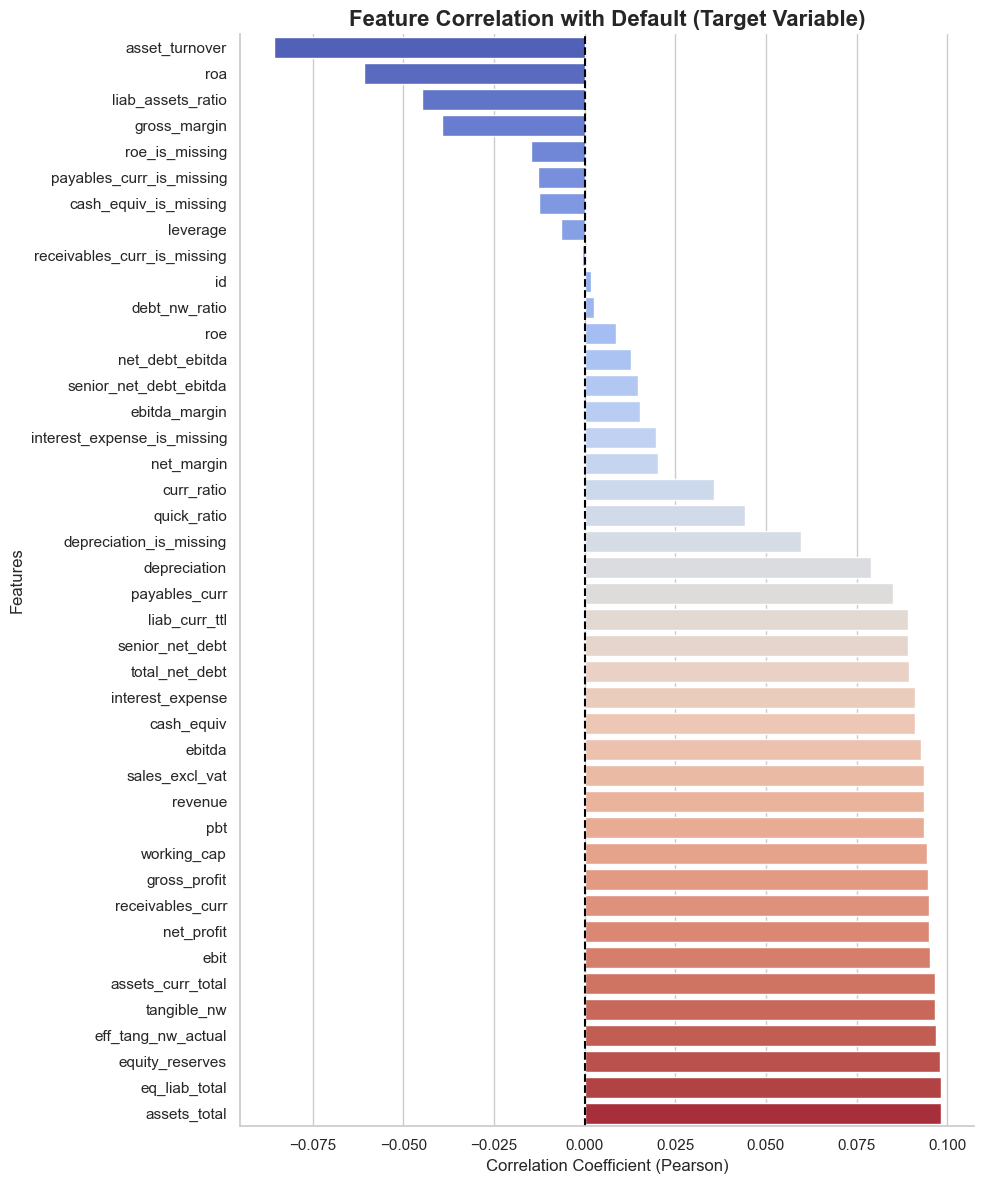

In [ ]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['default'].drop('default')
target_corr_sorted = target_corr.sort_values()

plt.figure(figsize=(10, 12))
sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette="coolwarm")

plt.title('Feature Correlation with Default (Target Variable)', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient (Pearson)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

Notice how the strongest negative correlation on the entire chart (asset_turnover) is only around -0.09, and the highest positive correlation (assets_total) is around +0.10. It says us in linear math (Pearson correlation), almost none of these variables have a strong, straight-line relationship with a company defaulting. This prooves the need of using the non-linear algos for the future (like XGBoost or Random Forest). Those models could find a real patterns and thresholds. 

We can notice that assets_total, net_profit, and revenue have a positive correlation with default. Probably, this could indicate a hiddent size effect, that Pearson correlation couldnt cover. Because you have a few massive, multi-billion-dollar companies in this dataset tx   hat did default, their sheer size is dragging the linear math upward.

In [ ]:
stacked_corr = corr_matrix.abs().unstack()
stacked_corr = stacked_corr.sort_values(ascending=False)

# Filter out the variables correlating with themselves (which is always 1.0)
stacked_corr = stacked_corr[stacked_corr < 1.0]

# Filter for only the highly correlated pairs 
high_corr_pairs = stacked_corr[stacked_corr > 0.85]
high_corr_pairs = high_corr_pairs.drop_duplicates()

print("--- RED ALERT: Highly Correlated Feature Pairs ---")
print("Consider dropping one feature from each of these pairs to prevent multicollinearity:\n")

for index, value in high_corr_pairs.items():
    feat1, feat2 = index
    print(f"{feat1} <--> {feat2}: {value:.3f}")

--- RED ALERT: Highly Correlated Feature Pairs ---
Consider dropping one feature from each of these pairs to prevent multicollinearity:

sales_excl_vat <--> revenue: 1.000
eq_liab_total <--> assets_total: 1.000
tangible_nw <--> eff_tang_nw_actual: 1.000
senior_net_debt <--> total_net_debt: 1.000
net_debt_ebitda <--> senior_net_debt_ebitda: 0.987
net_profit <--> pbt: 0.977
tangible_nw <--> equity_reserves: 0.972
eff_tang_nw_actual <--> equity_reserves: 0.972
ebitda <--> ebit: 0.966
liab_curr_ttl <--> assets_curr_total: 0.964
assets_total <--> equity_reserves: 0.963
eq_liab_total <--> equity_reserves: 0.963
gross_profit <--> ebitda: 0.958
assets_curr_total <--> assets_total: 0.956
eq_liab_total <--> assets_curr_total: 0.956
assets_total <--> liab_curr_ttl: 0.956
eq_liab_total <--> liab_curr_ttl: 0.956
curr_ratio <--> quick_ratio: 0.953
receivables_curr <--> assets_curr_total: 0.948
ebit <--> pbt: 0.940
liab_curr_ttl <--> payables_curr: 0.940
revenue <--> assets_curr_total: 0.939
assets_c

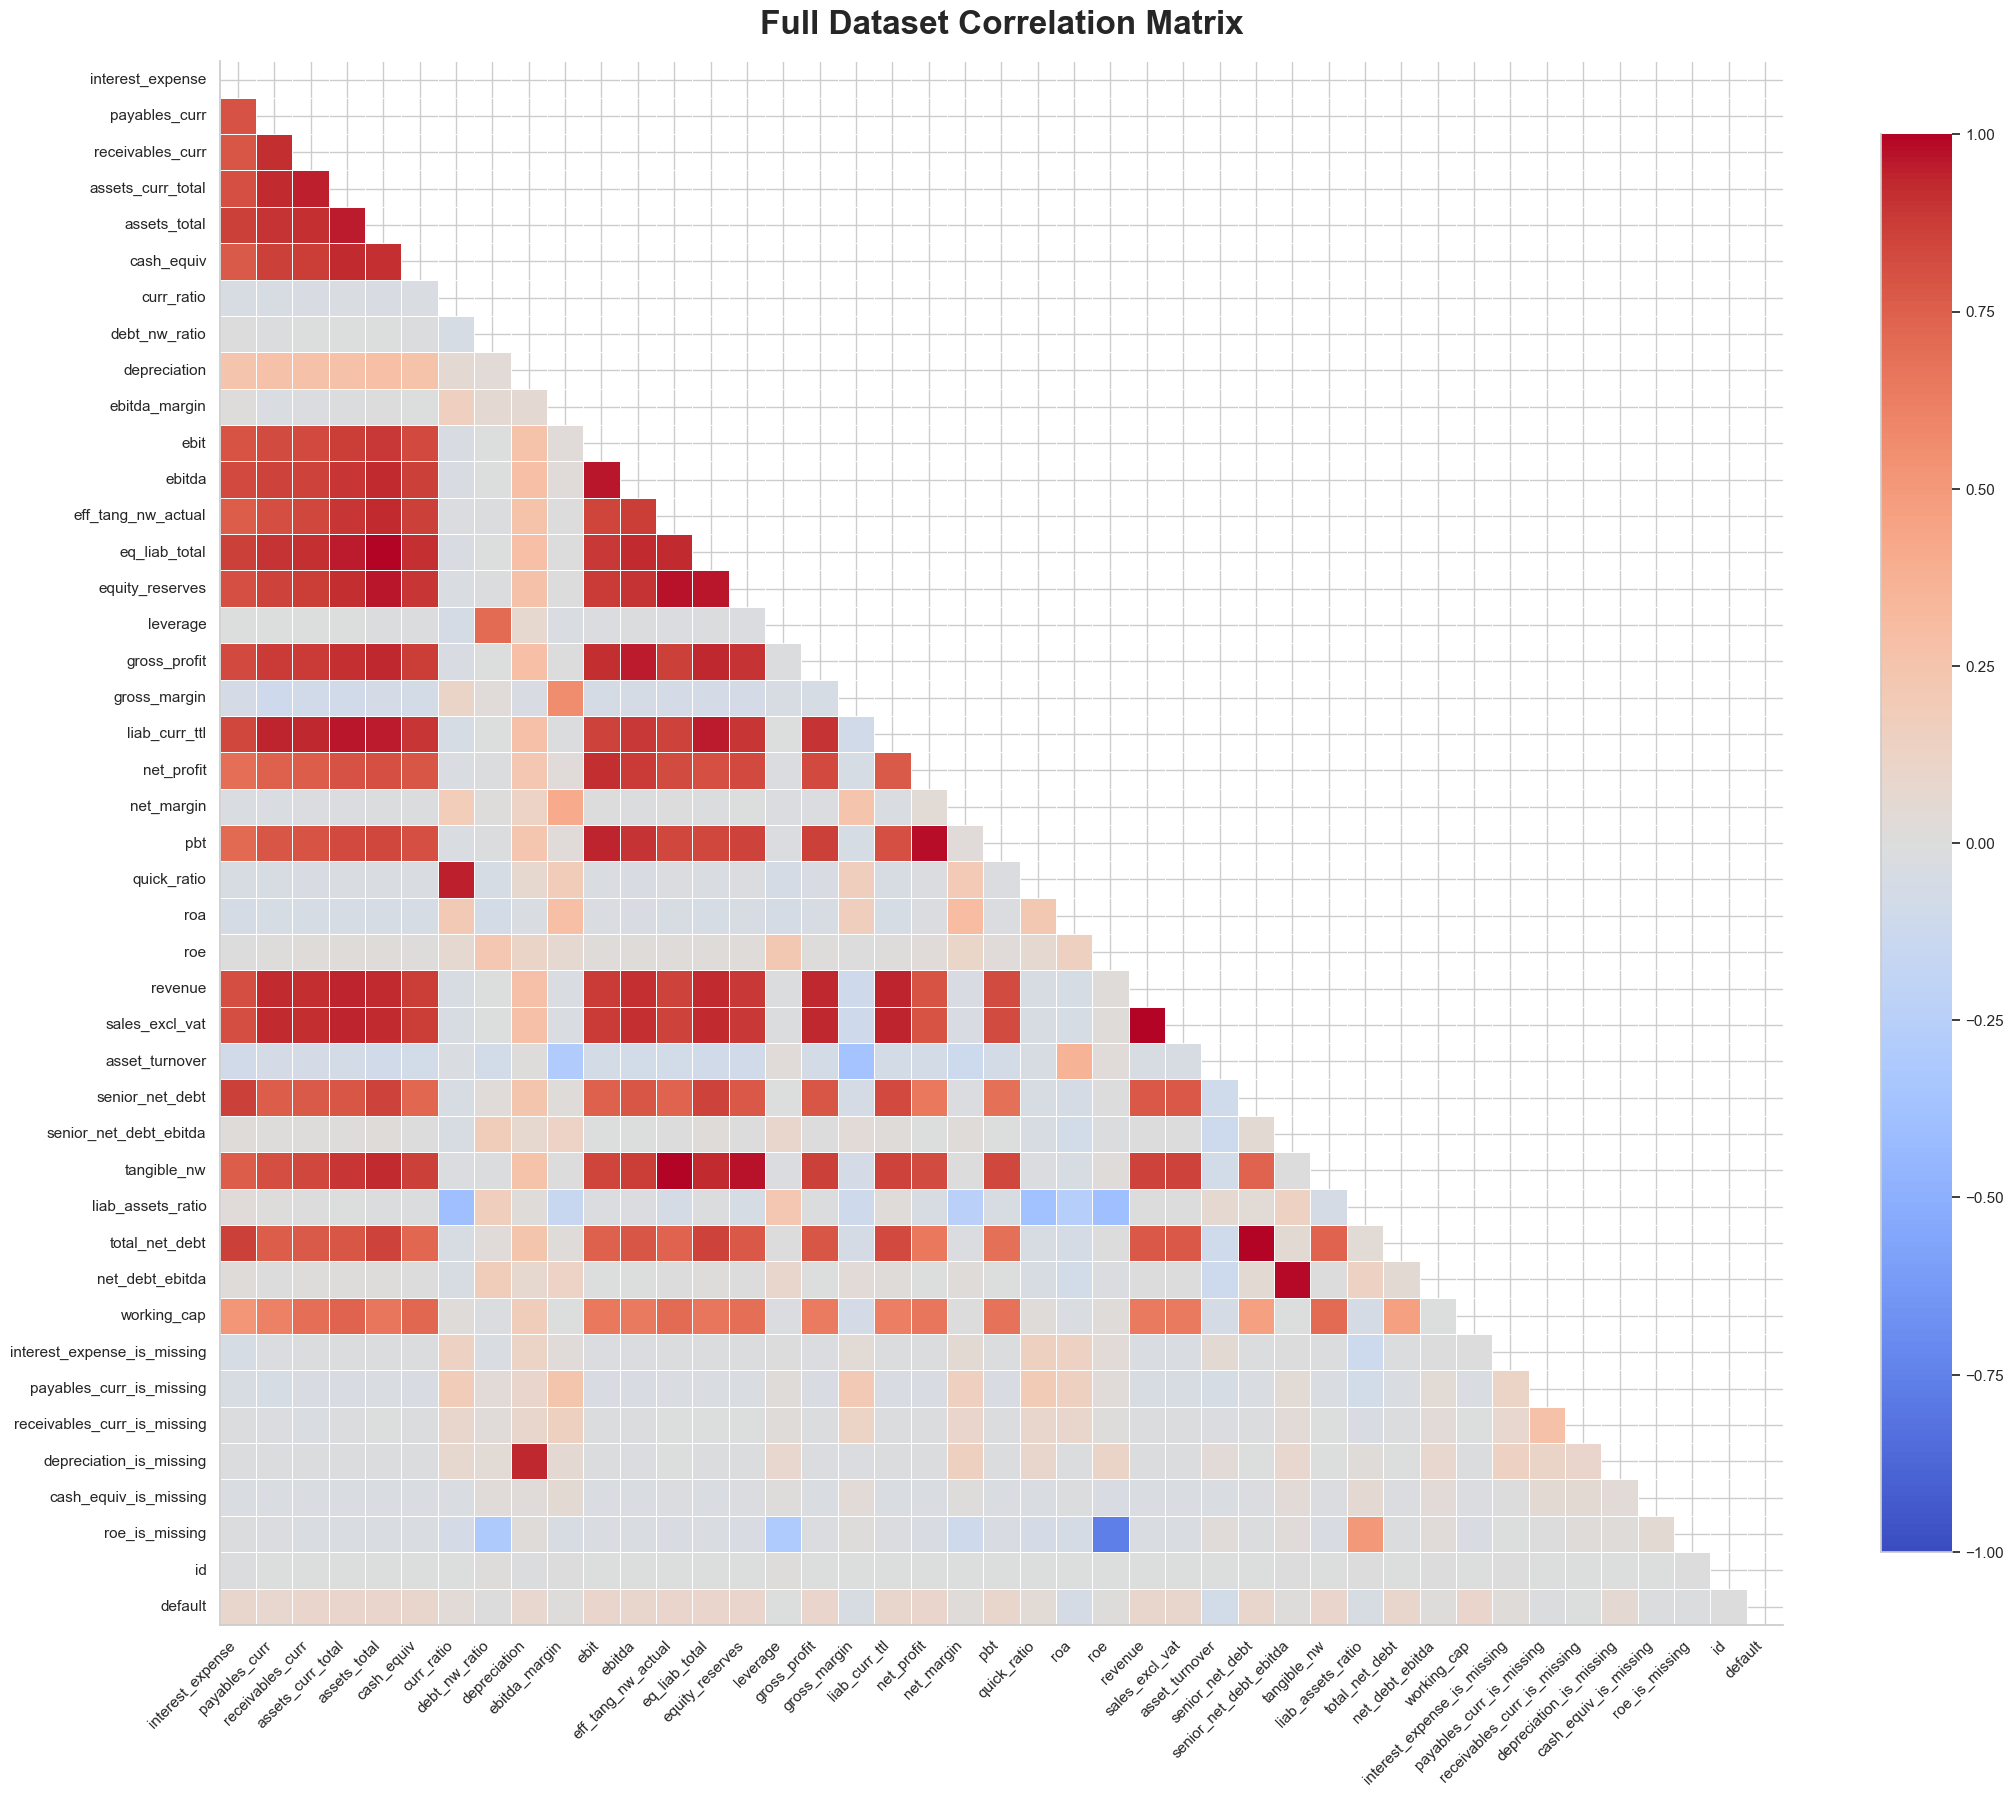

In [ ]:
full_corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(full_corr_matrix, dtype=bool))

plt.figure(figsize=(22, 20))
sns.heatmap(full_corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmax=1.0, vmin=-1.0, center=0.0, square=True, 
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Full Dataset Correlation Matrix', fontsize=24, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
full_corr_matrix = df.corr(numeric_only=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print("--- Full Dataset Correlation Matrix (Raw Values) ---")
print(full_corr_matrix)

pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.float_format')

--- Full Dataset Correlation Matrix (Raw Values) ---
                             interest_expense  payables_curr  \
interest_expense                        1.000          0.801   
payables_curr                           0.801          1.000   
receivables_curr                        0.788          0.918   
assets_curr_total                       0.810          0.924   
assets_total                            0.862          0.903   
cash_equiv                              0.773          0.865   
curr_ratio                             -0.045         -0.046   
debt_nw_ratio                           0.008         -0.009   
depreciation                            0.254          0.269   
ebitda_margin                           0.009         -0.030   
ebit                                    0.797          0.823   
ebitda                                  0.833          0.857   
eff_tang_nw_actual                      0.761          0.818   
eq_liab_total                           0.862      

Looking at the correlation matrix and tables, one of the first sthings we can notice is pairs that are 100% mathematically identical. Feeding both into a machine learning model adds zero new information and only slows the algorithm down. The identical pairs are:

- assets_total & eq_liab_total (1.000)

- revenue & sales_excl_vat (1.000): Exact synonyms in this database.

- tangible_nw & eff_tang_nw_actual (1.000)

- total_net_debt & senior_net_debt (1.000)

The second important note is visible high correlation cluster, where correlaiton is higher than 0.900. The first "cluster" has pbt (Profit Before Tax) and net_profit have a correlation of 0.977. Similarly, ebit and ebitda correlate at 0.966. We don't need four different ways to measure bottom-line profit. The second "cluster" have curr_ratio and quick_ratio have a correlation of 0.953. They measure the exact same short-term liquidity risk.

The third important note is nearly zero correlation of ratios (like leverage, debt_nw_ratio, and ebitda_margin) with amount variables, such as assets_total or revenue. This proves that ratios provide purely independent insights about a company's financial structure.

Taking correlation matrix into consideration, we can drop the following variables: 

- 'eq_liab_total',        (1.000 correlation with assets_total)
- 'sales_excl_vat',       (1.000 correlation with revenue)
- 'eff_tang_nw_actual',   (1.000 correlation with tangible_nw)
- 'senior_net_debt',      (1.000 correlation with total_net_debt)
- 'senior_net_debt_ebitda', (0.987 correlation with net_debt_ebitda)
- 'pbt',                  (0.977 correlation with net_profit)
- 'ebit',                 (0.966 correlation with ebitda)
- 'quick_ratio'           (0.953 correlation with curr_ratio)

Plotting distributions for 35 financial features...



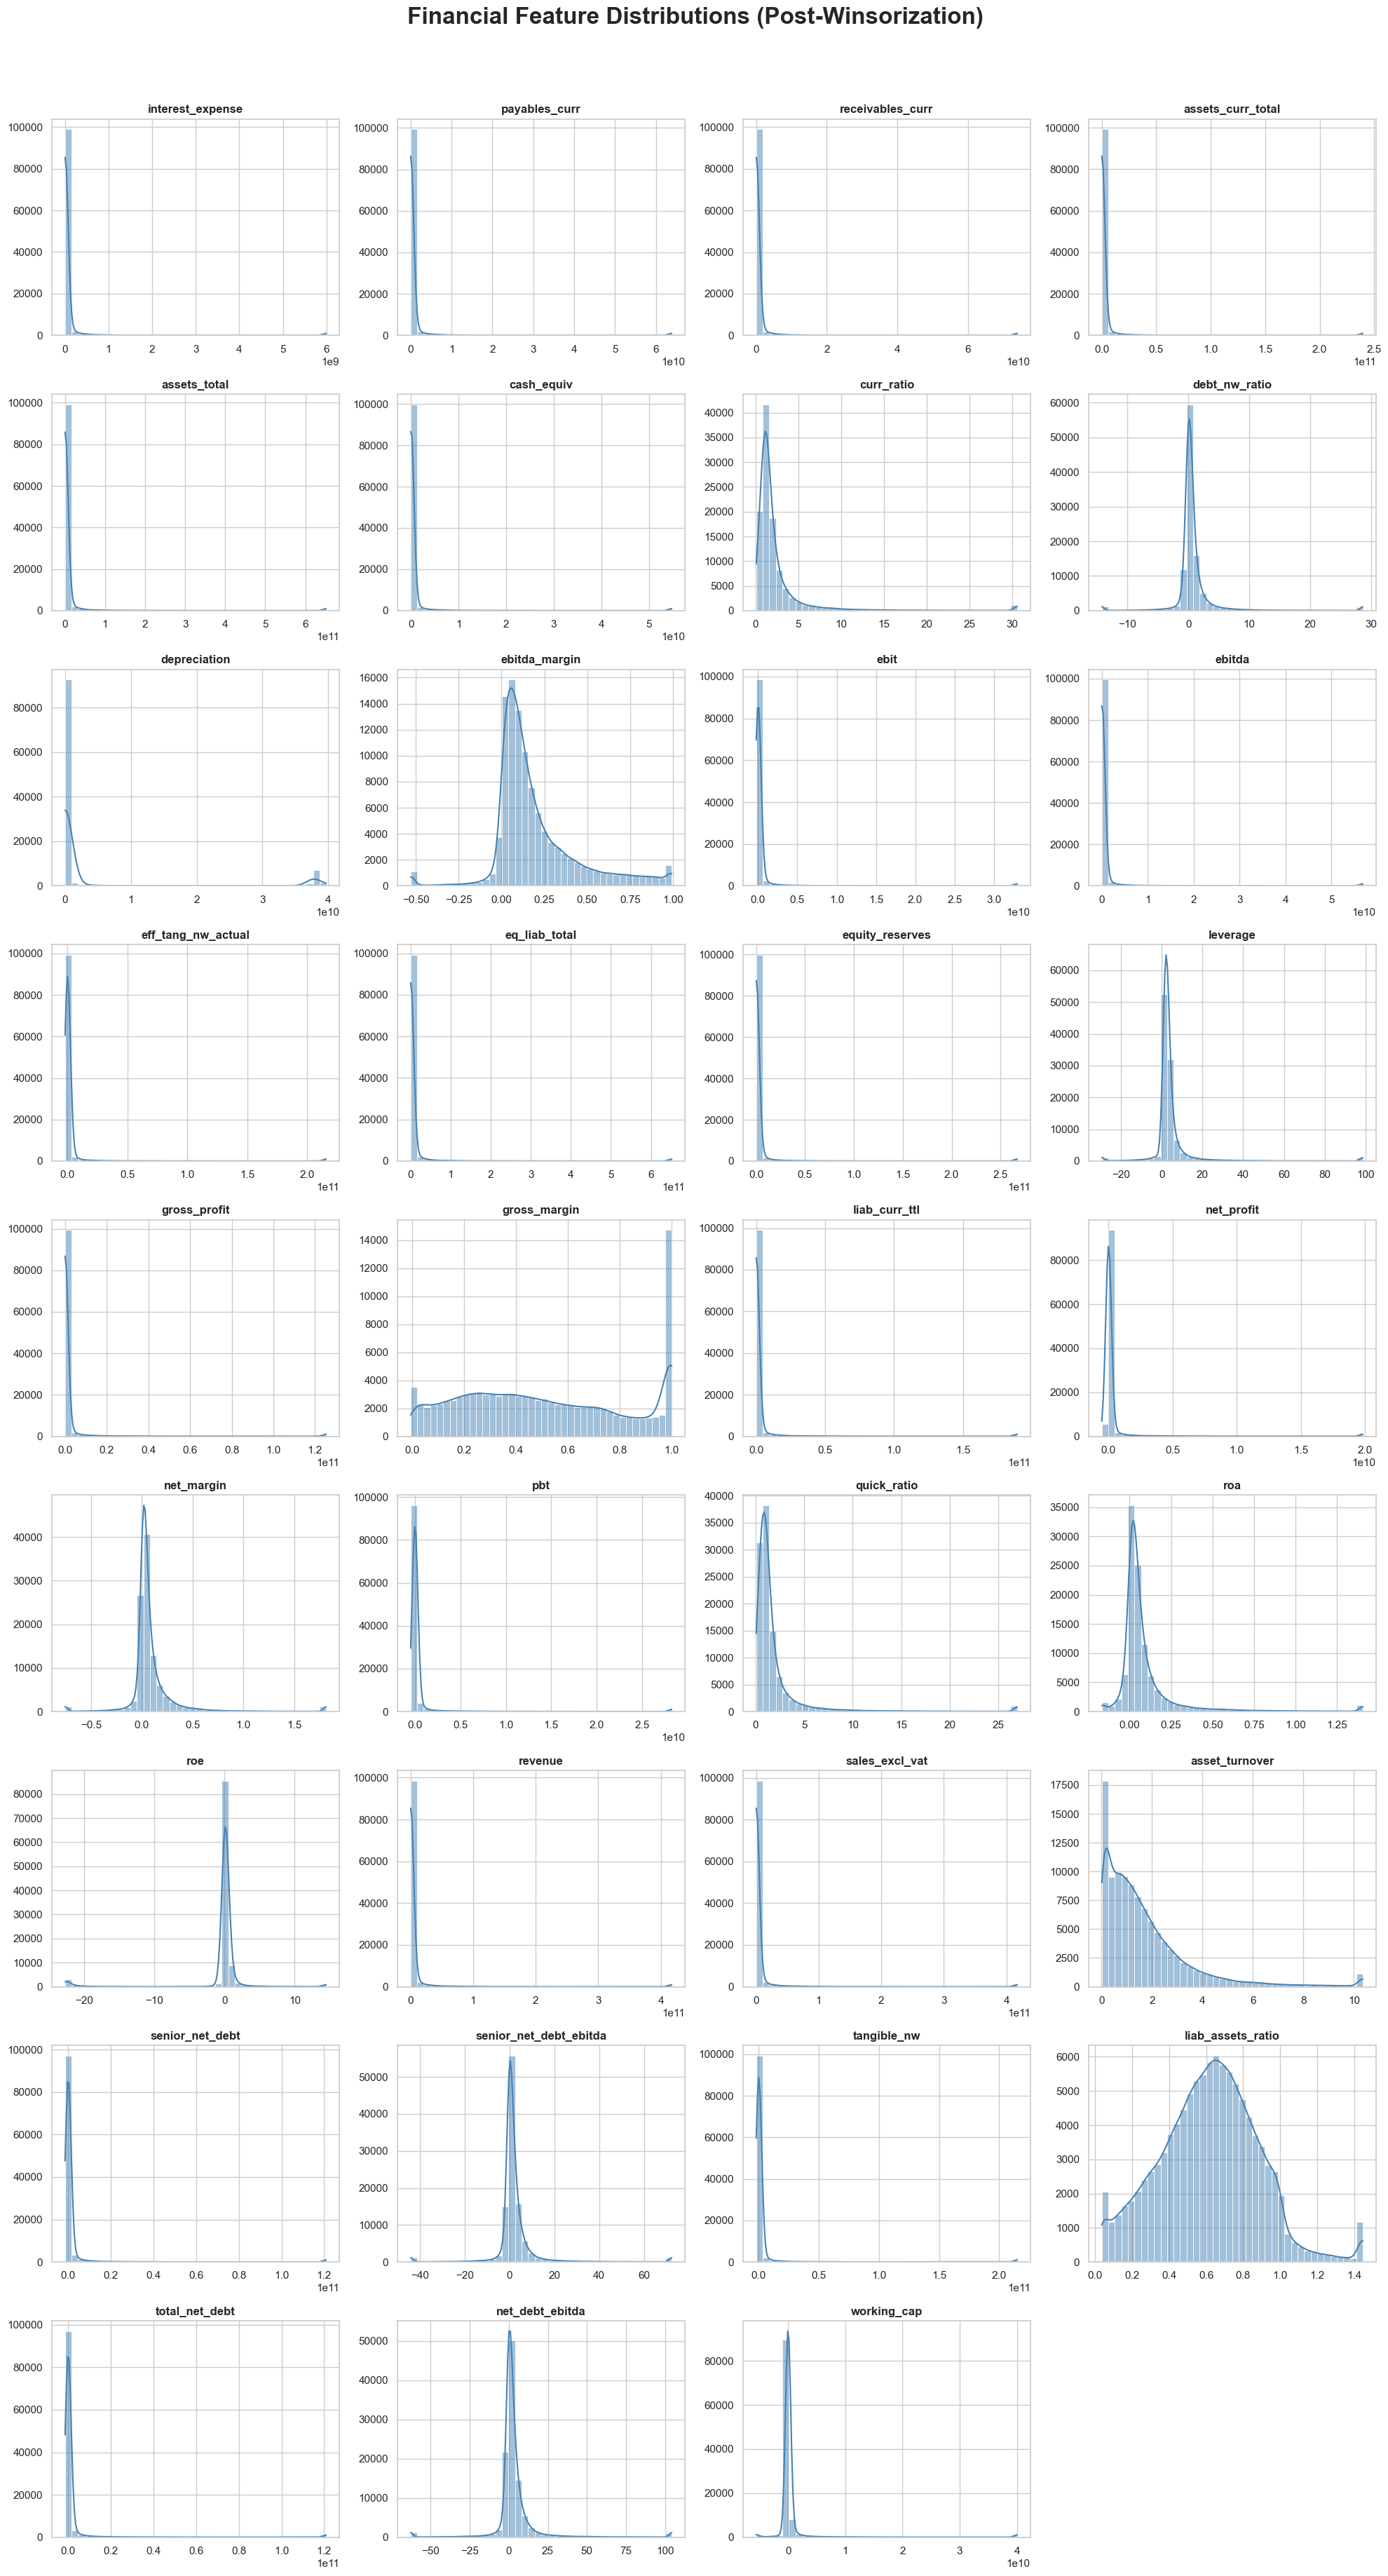

In [ ]:
# Isolate the continuous variables
cols_to_plot = [col for col in df.columns 
                if col not in ['id', 'obs_date', 'default'] 
                and not col.endswith('_is_missing')]

print(f"Plotting distributions for {len(cols_to_plot)} financial features...\n")

n_cols = 4 # 4 charts per row
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4)) # Dynamically scale the height based on how many rows we need
axes = axes.flatten() # Flatten the 2D grid so we can loop through it easily
for i, col in enumerate(cols_to_plot):
    # use a histogram with a Kernel Density Estimate (KDE) line to see the shape
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Financial Feature Distributions (Post-Winsorization)', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Based on the distribution plot for the variables, most of the variables heavily right-skewed. There is a massive spike right at zero, and a flat line extending to the right.Even though we chopped off the trillion-dollar anomalies with Winsorization durin the preprocessing step, the economic reality remains: 95% of the dataset is made up of "small" to "medium" businesses, and only a tiny fraction are multi-billion-dollar corporations. This pattern is noticable for: assests_total, interest_expense, revenue, ,cash_equiv, net_profit, senior_net_debt and other primarily money-related variables.

Look at variables like debt_nw_ratio, leverage, roe (Return on Equity), roa (Return on Assets), and the _ebitda ratios. Instead of an right-skewed "L-shape", these form tight, tall peaks (often centered around zero or a low positive number) with tails stretching in both directions. Because ratios divide a company's size out of the equation, they form much more normal-looking distributions. Most companies sit right in the middle (average leverage, average ROE), while a few highly successful or highly distressed companies stretch out the tails.

There are a few charts here that probably tell highly specific business case. liab_asset_ratio chart peaks in the middle, showing that most companies have a healthy mix of debt and assets, but then it tapers off to the right. gross_margin chart is basically a flat block from 0 to 1, with a massive spike exactly at 1.0. A gross margin of 1.0 (100%) could mean the company is a purely digital or service-based business with zero physical "Cost of Goods Sold" (like a software company or a consulting firm). sset_turnover chart forms a perfect, smooth exponential decay curve.

Based on the distribution charts we also can estimate which of the variables should or could be log-transformed for the future modelling. 

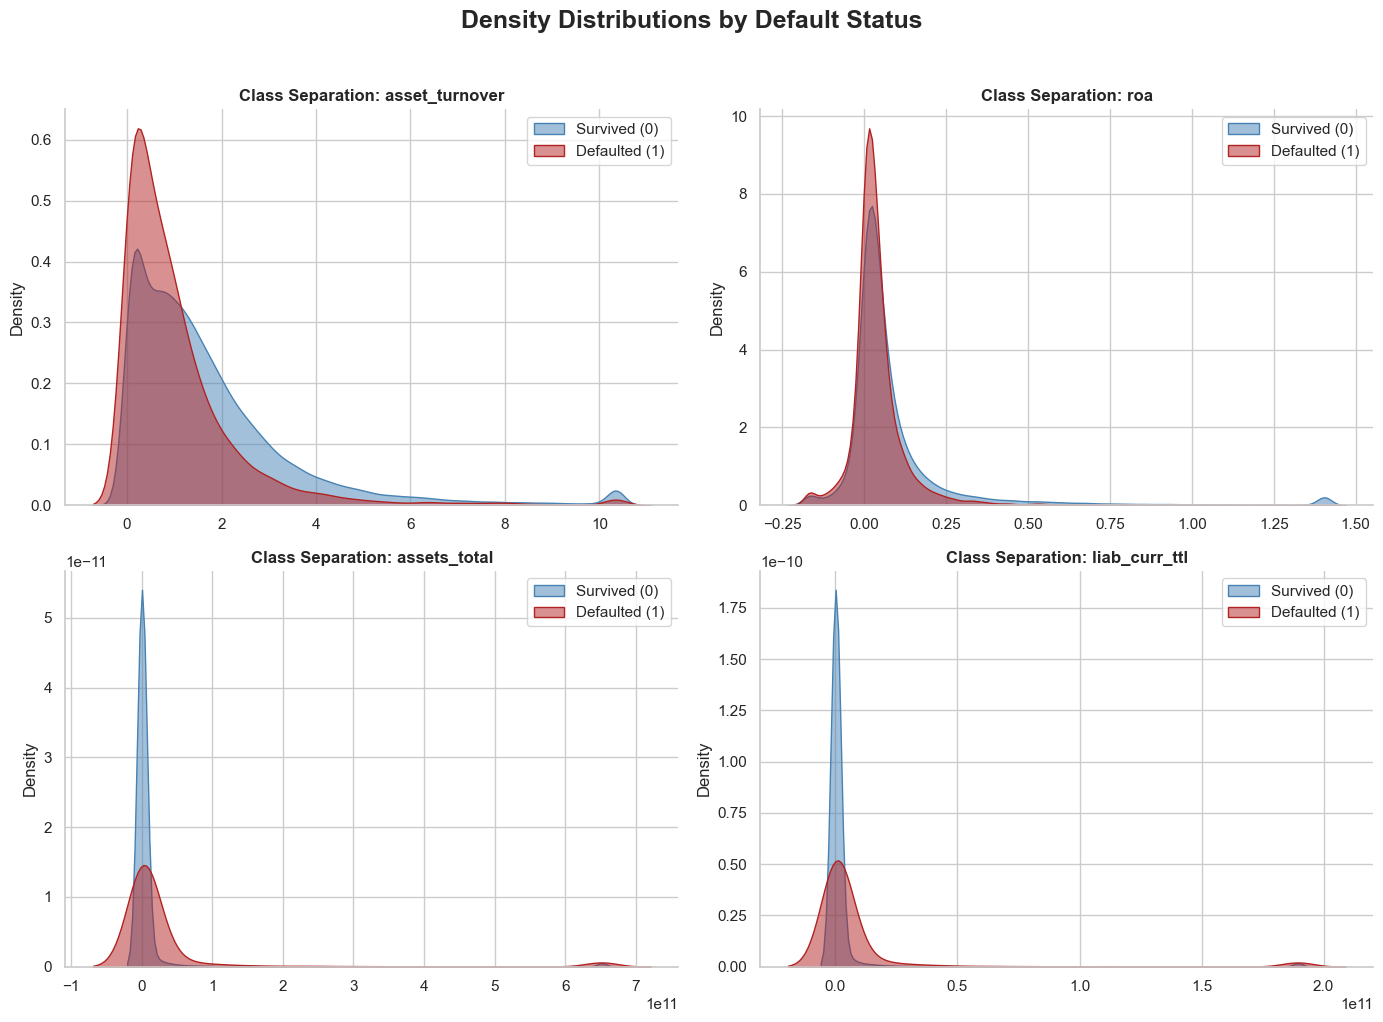

In [ ]:
# the 4 most highly correlated features (positive and negative)
top_features = ['asset_turnover', 'roa', 'assets_total', 'liab_curr_ttl']


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(top_features):
    # Plot Survivors (0)
    sns.kdeplot(data=df[df['default'] == 0], x=col, 
                fill=True, color='steelblue', label='Survived (0)', alpha=0.5, ax=axes[i])
    
    # Plot Defaulters (1)
    sns.kdeplot(data=df[df['default'] == 1], x=col, 
                fill=True, color='firebrick', label='Defaulted (1)', alpha=0.5, ax=axes[i])
    
    axes[i].set_title(f'Class Separation: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')
    axes[i].legend()

fig.suptitle('Density Distributions by Default Status', fontsize=18, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

A class separation analysis of the top correlated features revealed that efficiency ratios (such as Asset Turnover and ROA) provide strong discriminatory power between surviving (companies that didn't go bankrupt or default on its loans within the next 12 months) and defaulting companies. Conversely, absolute scale metrics (such as Total Assets and Current Liabilities) exhibit virtually identical density distributions for both classes. This visually confirms that corporate defaults in this dataset are driven by poor operational efficiency and margin collapse, rather than the absolute size of the company's balance sheet.

Successfully extracted 'obs_year' and 'obs_month' features.



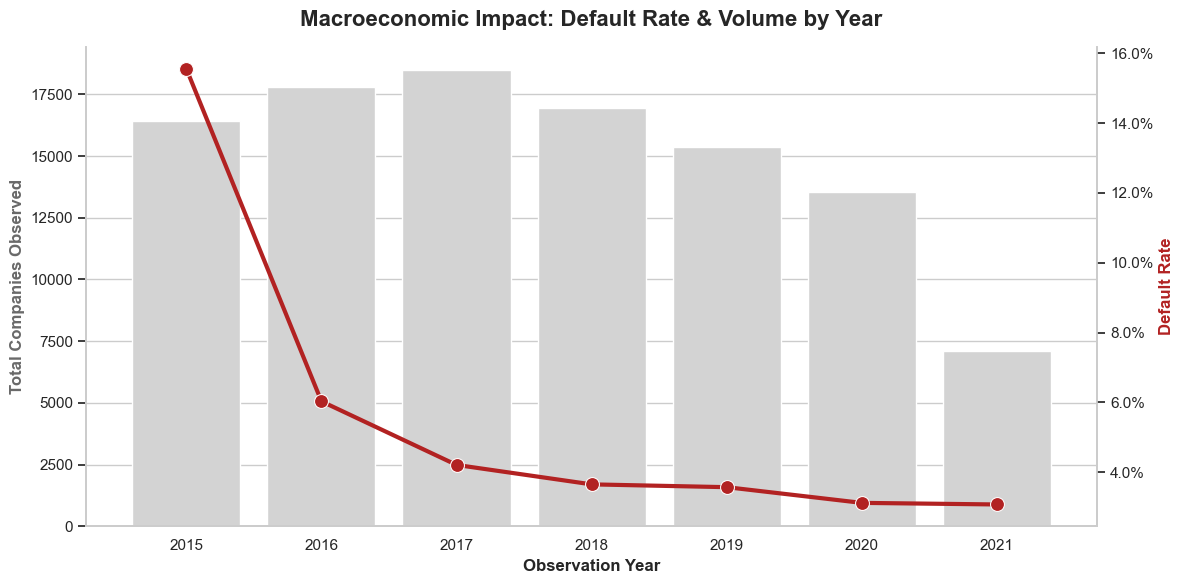

Original 'obs_date' string column dropped. Data is strictly numeric.


In [ ]:
# Convert strings to datetime objects and extract features 

df['obs_date'] = pd.to_datetime(df['obs_date'])
df['obs_year'] = df['obs_date'].dt.year
df['obs_month'] = df['obs_date'].dt.month
print("Successfully extracted 'obs_year' and 'obs_month' features.\n")

# Group data by Year 
yearly_stats = df.groupby('obs_year').agg(
    total_companies=('id', 'count'),
    default_rate=('default', 'mean')
).reset_index()

#  the Dual-Axis Macroeconomic Chart
fig, ax1 = plt.subplots(figsize=(12, 6))
# Axis 1: Bar chart for Volume (How many companies were observed that year?)
sns.barplot(data=yearly_stats, x='obs_year', y='total_companies', color='lightgray', ax=ax1)
ax1.set_ylabel('Total Companies Observed', fontsize=12, fontweight='bold', color='dimgray')
ax1.set_xlabel('Observation Year', fontsize=12, fontweight='bold')

# Axis 2: Line chart for Default Rate (Did a specific year crash?)
ax2 = ax1.twinx()
# Get the x-tick positions from ax1 to align the line plot perfectly
xticks = range(len(yearly_stats['obs_year']))
sns.lineplot(x=xticks, y=yearly_stats['default_rate'], 
             color='firebrick', marker='o', linewidth=3, markersize=10, ax=ax2)

ax2.set_ylabel('Default Rate', fontsize=12, fontweight='bold', color='firebrick')
ax2.yaxis.set_major_formatter(PercentFormatter(1.0)) # Format as percentage (e.g., 5.0%)
ax2.grid(False) # Turn off grid for the second axis to keep it clean

plt.title('Macroeconomic Impact: Default Rate & Volume by Year', fontsize=16, fontweight='bold', pad=15)
sns.despine(right=False)
plt.tight_layout()
plt.show()
df = df.drop(columns=['obs_date'])

print("Original 'obs_date' string column dropped. Data is strictly numeric.")

The plot above is Dual-Axis Macroeconomic Chart. The Bars (Background) show us your Volume (how many companies were observed in that year). The Line (Foreground) show us the Default Rate (perantage of the defaults) for that year. We can see from the plot that the default rate in 2015 was aquite high hovering around 15.5%. This is nearly triple the average default rate of the rest of the dataset. The default rate plummets to ~6% in 2016 and steadily goes down to a highly stable, predictable ~3% by 2020/2021. Notice that 2020 (the start of the pandemic) didn't cause a spike in defaults here. In fact, the default rate dropped to its lowest point. Looking at the grey bars (the volume of companies) we can see that the number of observed companies peaks in 2017 (over 18,000) and steadily drops, ending with a massive plunge in 2021 (only ~7,000 companies). Seems like the data collection stops in the 2021 year. 

Overall, we can see that the obs_date variable also plays crusial role in default prediction and could be extracted as a numeric feature. 